In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 150
plt.rcParams["font.size"] = 12

RESULTS_PATH = "../../results/metrics/exp02_zeroshot_results.csv"
PLOTS_PATH   = "../../results/plots"

In [2]:
df = pd.read_csv(RESULTS_PATH)
print(f"Примеров в тесте: {len(df)}")
print(f"Уникальных интентов: {df['true_intent'].nunique()}")
df.head(3)

Примеров в тесте: 3578
Уникальных интентов: 151


,text,true_intent,pred_prompt1,correct_prompt1,pred_prompt2,correct_prompt2,pred_prompt3,correct_prompt3
0,yearly salary,income,yes,0,yes,0,redeem_rewards,0
1,how do i activate you,what_is_your_name,are_you_a_bot,0,maybe,0,what_can_i_ask_you,0
2,y check engine light currently came on and i n...,schedule_maintenance,are_you_a_bot,0,do_you_have_pets,0,whisper_mode,0


In [4]:
metrics = {
    "Промпт": ["Промпт 1 (Короткий)", "Промпт 2 (Описательный)", "Промпт 3 (Вопрос)"],
    "Accuracy": [
        df["correct_prompt1"].mean(),
        df["correct_prompt2"].mean(),
        df["correct_prompt3"].mean(),
    ],
    "Fine-Tuning (эталон)": [0.9424, 0.9424, 0.9424],
}

metrics_df = pd.DataFrame(metrics)
metrics_df["Accuracy"] = metrics_df["Accuracy"].round(4)
metrics_df["Отставание от FT"] = (metrics_df["Fine-Tuning (эталон)"] - metrics_df["Accuracy"]).round(4)
metrics_df

,Промпт,Accuracy,Fine-Tuning (эталон),Отставание от FT
0,Промпт 1 (Короткий),0.0528,0.9424,0.8896
1,Промпт 2 (Описательный),0.0159,0.9424,0.9265
2,Промпт 3 (Вопрос),0.1688,0.9424,0.7736


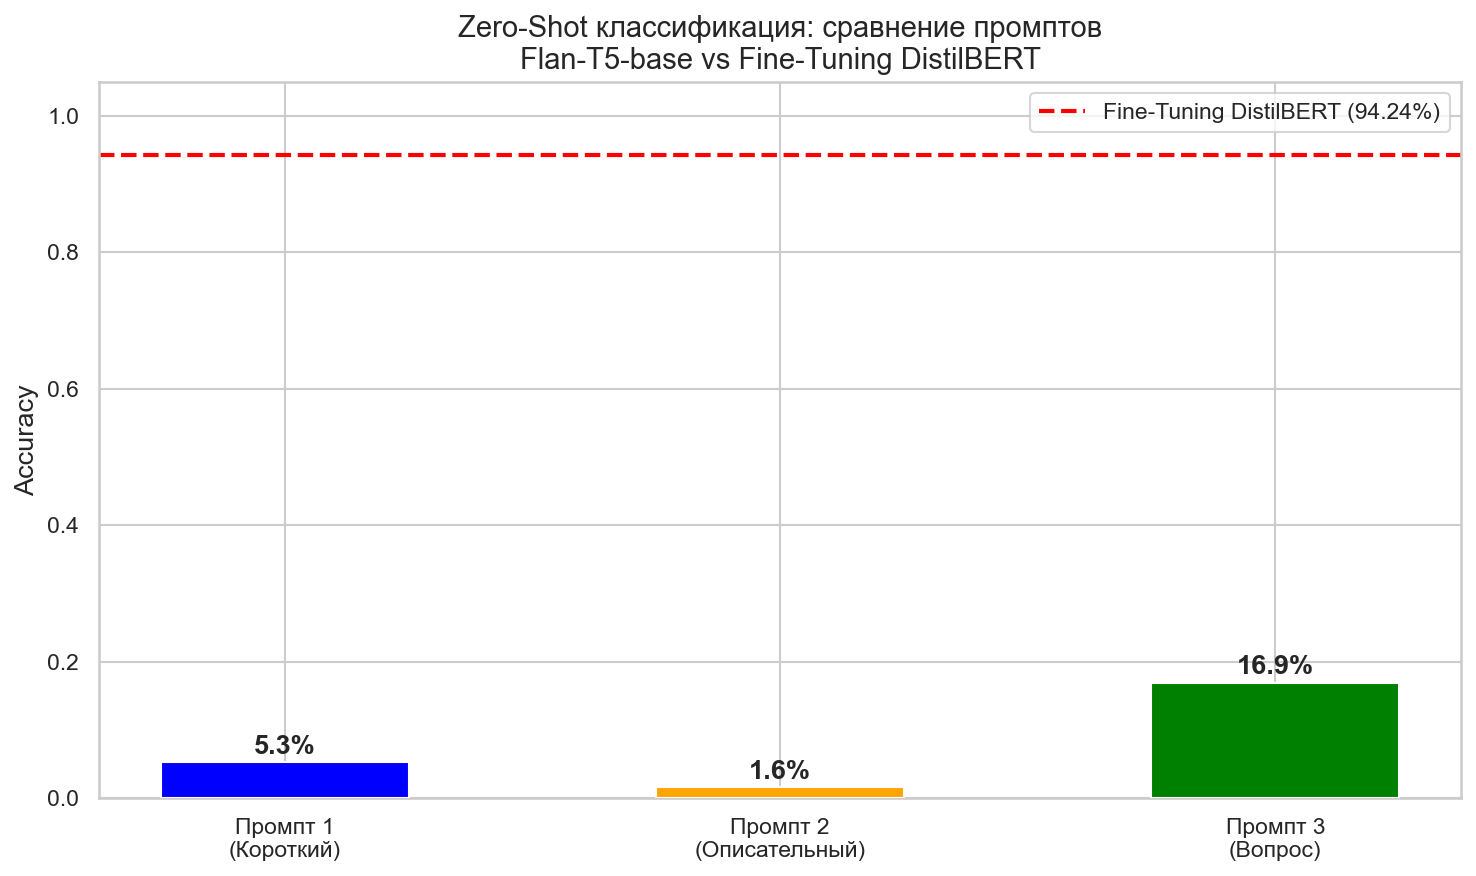

График сохранён.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

prompts = ["Промпт 1\n(Короткий)", "Промпт 2\n(Описательный)", "Промпт 3\n(Вопрос)"]
accuracies = [
    df["correct_prompt1"].mean(),
    df["correct_prompt2"].mean(),
    df["correct_prompt3"].mean(),
]
colors = ['blue', 'orange', 'green']

bars = ax.bar(prompts, accuracies, color=colors, width=0.5, zorder=3)

# Линия Fine-Tuning эталона
ax.axhline(y=0.9424, color="red", linestyle="--", linewidth=2, label="Fine-Tuning DistilBERT (94.24%)")

# Подписи над столбцами
for bar, acc in zip(bars, accuracies):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{acc:.1%}",
        ha="center", va="bottom", fontsize=13, fontweight="bold"
    )

ax.set_ylim(0, 1.05)
ax.set_ylabel("Accuracy", fontsize=13)
ax.set_title("Zero-Shot классификация: сравнение промптов\nFlan-T5-base vs Fine-Tuning DistilBERT", fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis="y", zorder=0)

plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/exp02_prompt_comparison.png", dpi=150)
plt.show()

/var/folders/5c/g1ncpvqd1hd70y92g4q3v09h0000gn/T/ipykernel_19890/1550215154.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["accuracy"], y=top10.index, palette="Blues_d", ax=ax)


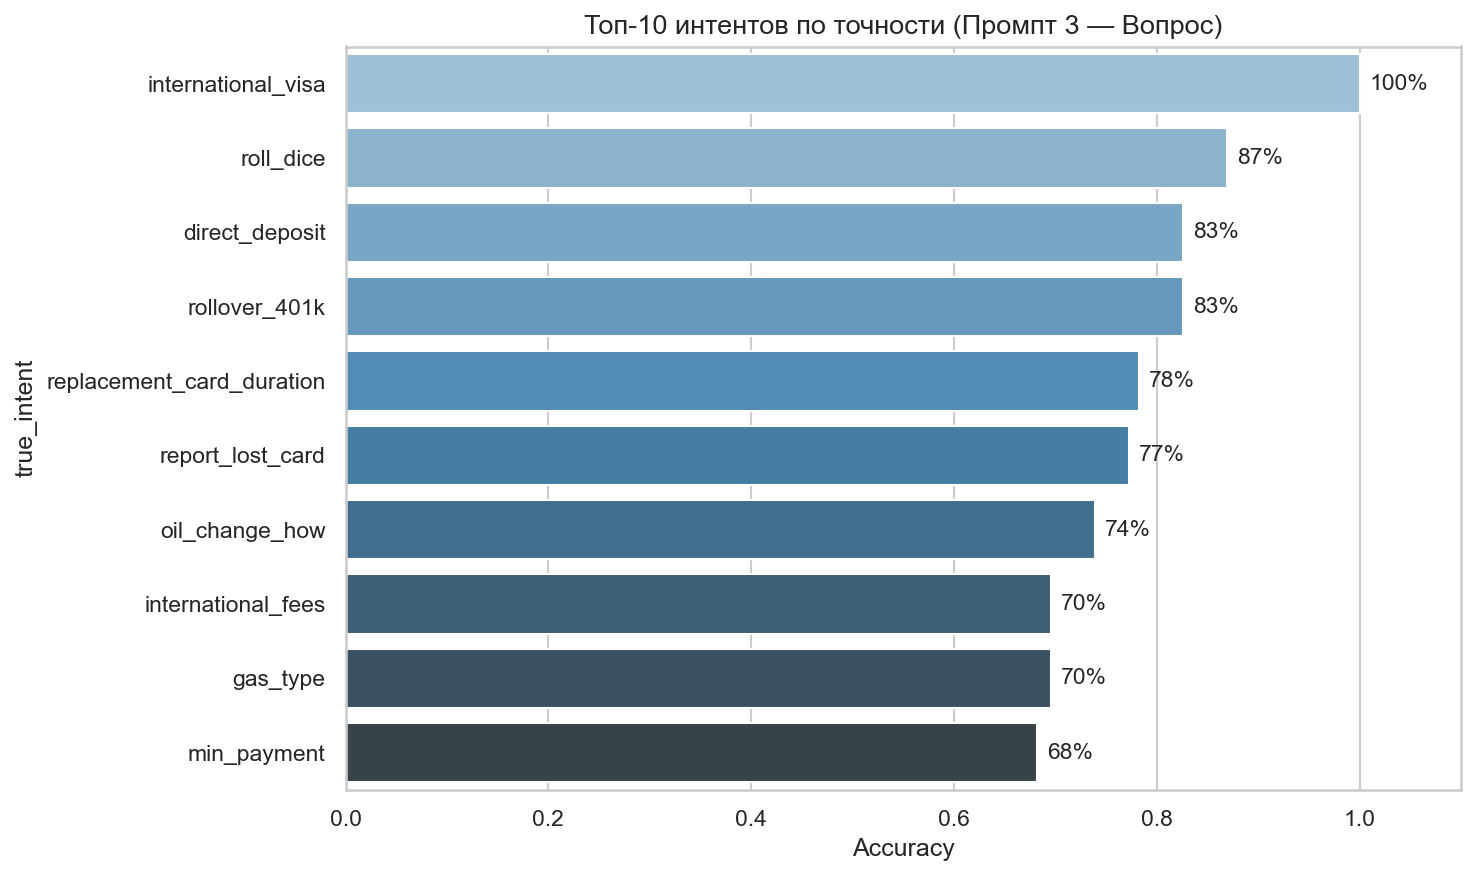

In [6]:
per_intent = df.groupby("true_intent")["correct_prompt3"].agg(["sum", "count"])
per_intent["accuracy"] = per_intent["sum"] / per_intent["count"]
per_intent = per_intent.sort_values("accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top10 = per_intent.head(10)
sns.barplot(x=top10["accuracy"], y=top10.index, palette="Blues_d", ax=ax)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("Топ-10 интентов по точности (Промпт 3 — Вопрос)", fontsize=13)
ax.set_xlim(0, 1.1)

for i, (idx, row) in enumerate(top10.iterrows()):
    ax.text(row["accuracy"] + 0.01, i, f"{row['accuracy']:.0%}", va="center", fontsize=11)

plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/exp02_top10_intents.png", dpi=150)
plt.show()

/var/folders/5c/g1ncpvqd1hd70y92g4q3v09h0000gn/T/ipykernel_19890/1913553454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_preds.values, y=top_preds.index, palette="Oranges_d", ax=ax)
/var/folders/5c/g1ncpvqd1hd70y92g4q3v09h0000gn/T/ipykernel_19890/1913553454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_preds.values, y=top_preds.index, palette="Oranges_d", ax=ax)


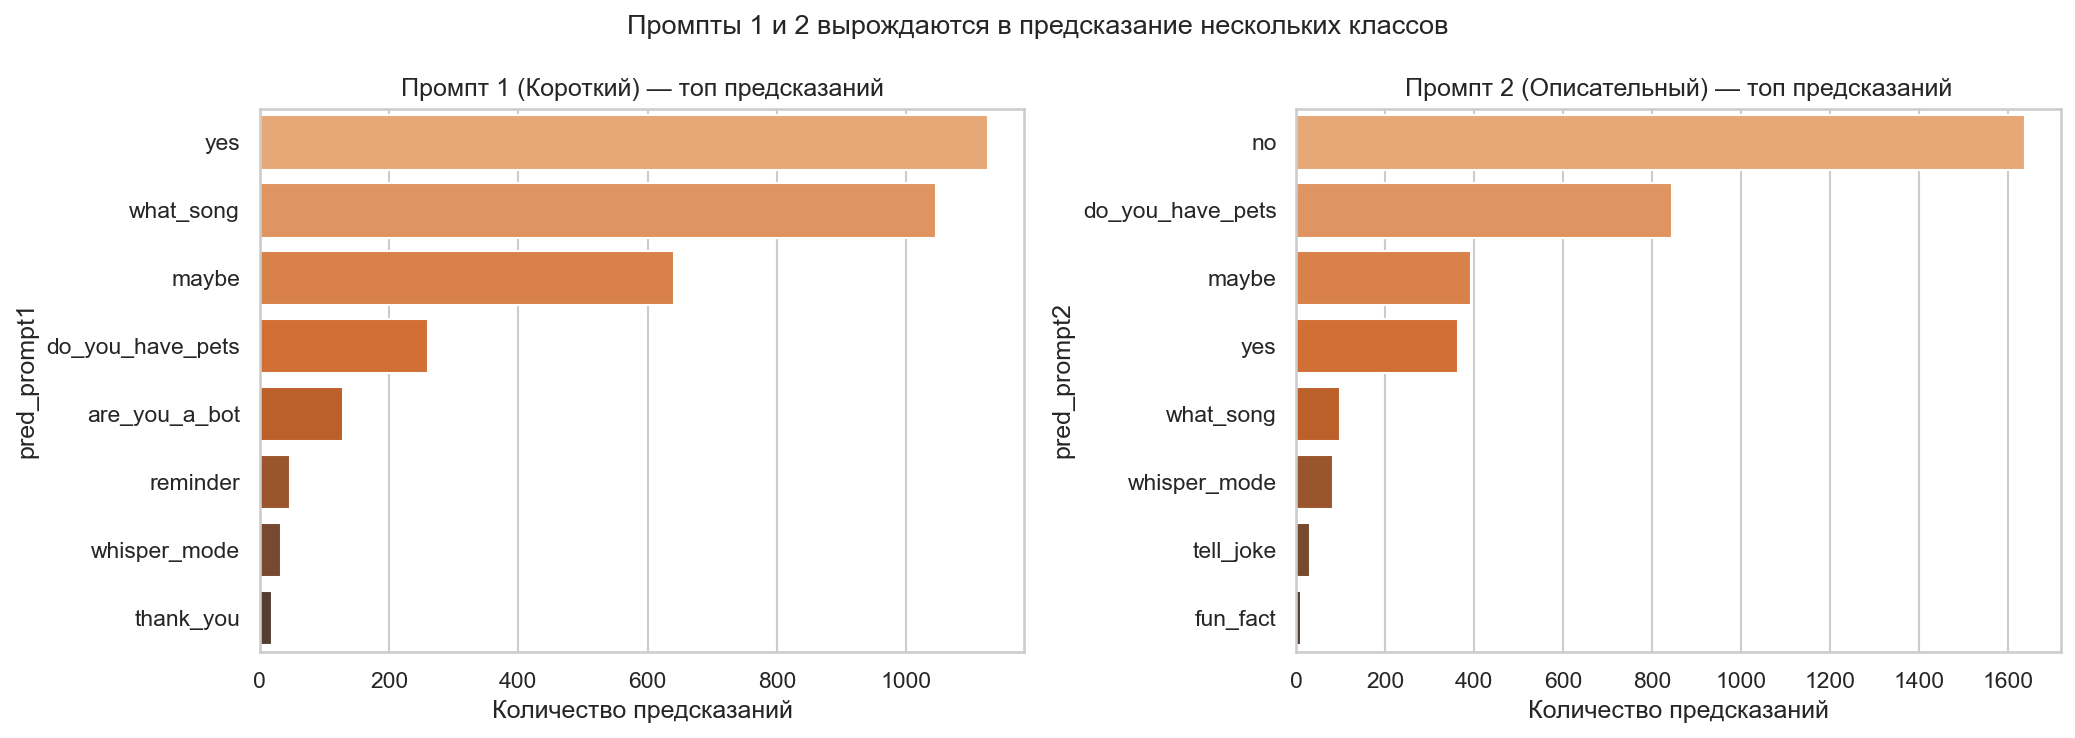

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["pred_prompt1", "pred_prompt2"],
    ["Промпт 1 (Короткий) — топ предсказаний", "Промпт 2 (Описательный) — топ предсказаний"]
):
    top_preds = df[col].value_counts().head(8)
    sns.barplot(x=top_preds.values, y=top_preds.index, palette="Oranges_d", ax=ax)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Количество предсказаний")

plt.suptitle("Промпты 1 и 2 вырождаются в предсказание нескольких классов", fontsize=13)
plt.tight_layout()
plt.savefig(f"{PLOTS_PATH}/exp02_degenerate_predictions.png", dpi=150)
plt.show()